# Heart Disease Prediction — Certification Project III
**Edureka | Data Science and Machine Learning Program**

**Objective:**
1. Build the best performing model to determine probability of heart disease or attack.
2. Identify the most important drivers for heart disease or attack.

## 1. Import Libraries and Load Dataset

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

print('Libraries imported successfully.')

Libraries imported successfully.


In [12]:
df = pd.read_csv('data/heartdisease.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (253680, 16)


,HeartDiseaseorAttack,HighBP,HighChol,BMI,Smoker,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,1.0,0.0,18.0,15.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,25.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,0.0,30.0,30.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,27.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,24.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,0.0,11.0,5.0,4.0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Overview

In [13]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   BMI                   253680 non-null  float64
 4   Smoker                253680 non-null  float64
 5   Diabetes              253680 non-null  float64
 6   PhysActivity          253680 non-null  float64
 7   Fruits                253680 non-null  float64
 8   Veggies               253680 non-null  float64
 9   HvyAlcoholConsump     253680 non-null  float64
 10  MentHlth              253680 non-null  float64
 11  PhysHlth              253680 non-null  float64
 12  Sex                   253680 non-null  float64
 13  Age                   253680 non-null  float64
 14  Education             253680 non-null  flo

In [14]:
print('=== Statistical Summary ===')
df.describe().T

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Diabetes,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0
HvyAlcoholConsump,253680.0,0.056197,0.230302,0.0,0.0,0.0,0.0,1.0


In [15]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

=== Missing Values ===
No missing values found.


In [16]:
print('=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'Number of duplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')

=== Duplicate Rows ===
Number of duplicate rows: 42852
Duplicates removed. New shape: (210828, 16)


=== Target Variable Distribution ===
                       Count  Percentage (%)
HeartDiseaseorAttack                        
0.0                   187485           88.93
1.0                    23343           11.07


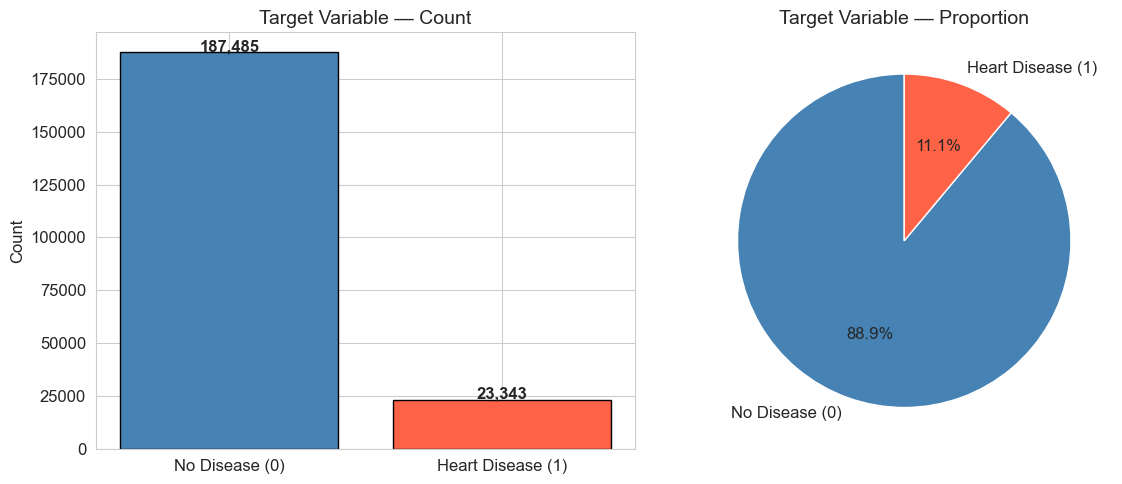


Observation: The dataset is highly imbalanced — ~91% No Disease vs ~9% Heart Disease.


In [17]:
print('=== Target Variable Distribution ===')
target_counts = df['HeartDiseaseorAttack'].value_counts()
target_pct = df['HeartDiseaseorAttack'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)}))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(['No Disease (0)', 'Heart Disease (1)'], target_counts.values,
          color=['steelblue', 'tomato'], edgecolor='black')
ax[0].set_title('Target Variable — Count', fontsize=14)
ax[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

ax[1].pie(target_counts.values, labels=['No Disease (0)', 'Heart Disease (1)'],
          colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
ax[1].set_title('Target Variable — Proportion', fontsize=14)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nObservation: The dataset is highly imbalanced — ~91% No Disease vs ~9% Heart Disease.')

### 2.2 Univariate Analysis

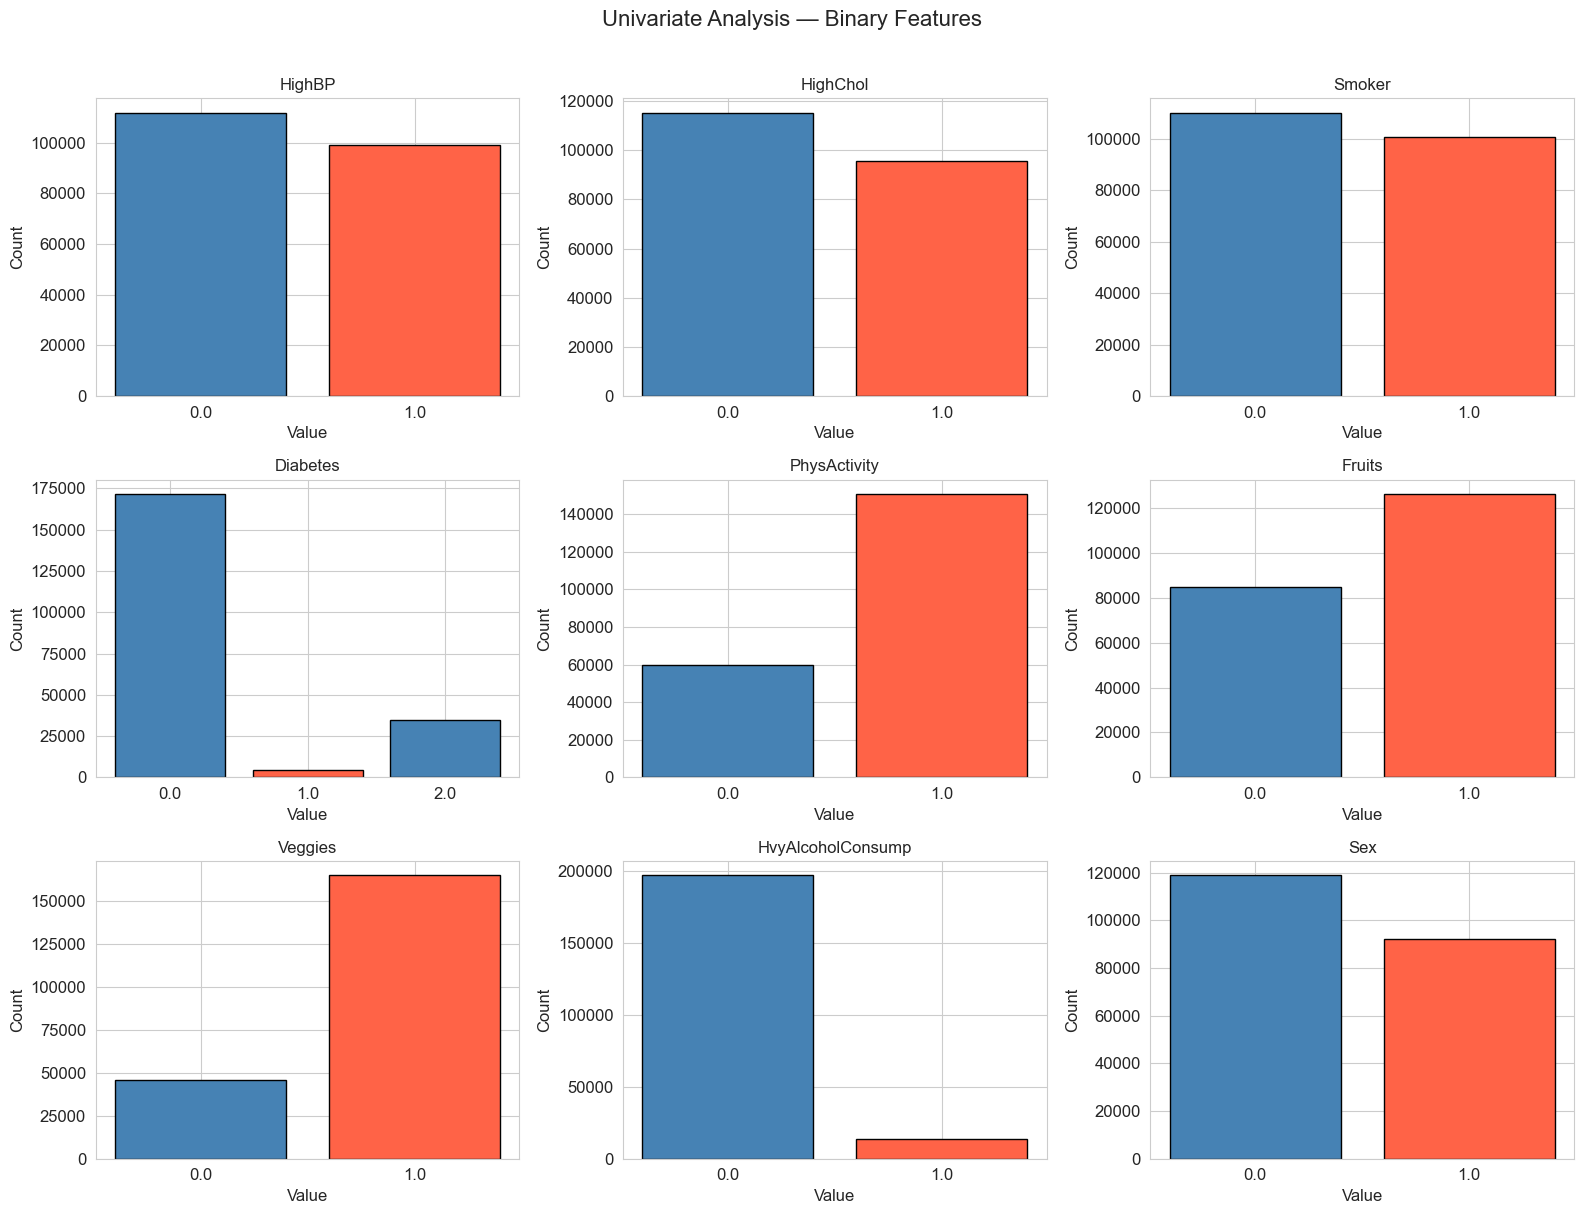

In [18]:
binary_cols = ['HighBP', 'HighChol', 'Smoker', 'Diabetes', 'PhysActivity',
               'Fruits', 'Veggies', 'HvyAlcoholConsump', 'Sex']
numeric_cols = ['BMI', 'MentHlth', 'PhysHlth']
ordinal_cols = ['Age', 'Education', 'Income']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()
for i, col in enumerate(binary_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=['steelblue', 'tomato'], edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Analysis — Binary Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('univariate_binary.png', dpi=120, bbox_inches='tight')
plt.show()

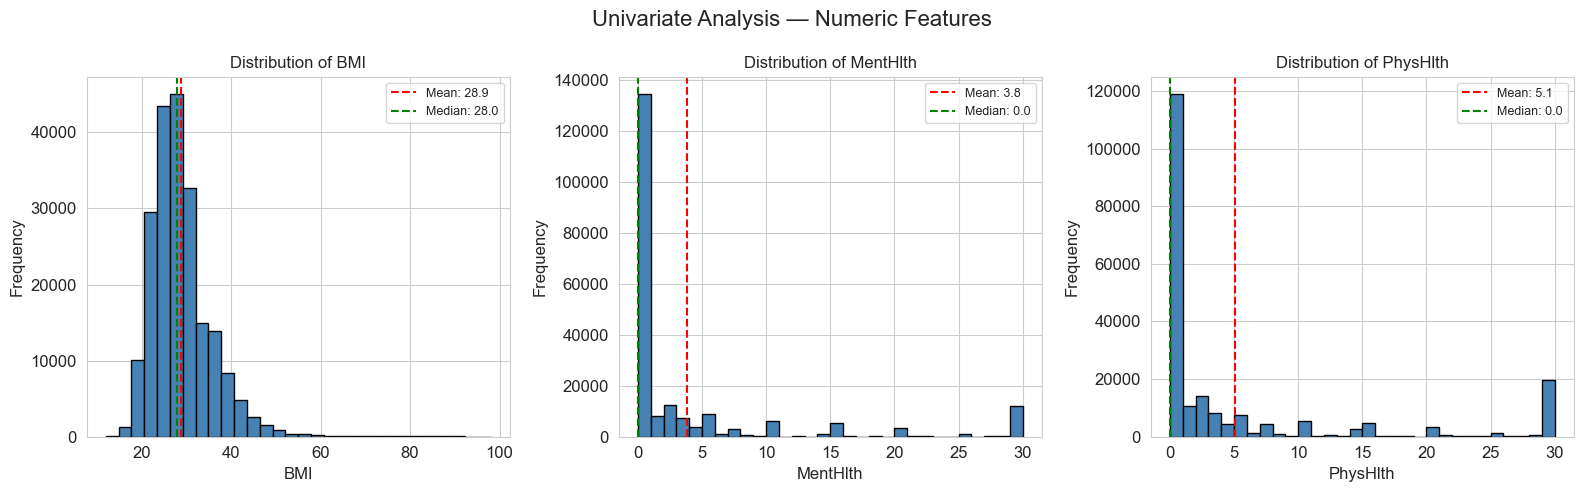

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Univariate Analysis — Numeric Features', fontsize=16)
plt.tight_layout()
plt.savefig('univariate_numeric.png', dpi=120, bbox_inches='tight')
plt.show()

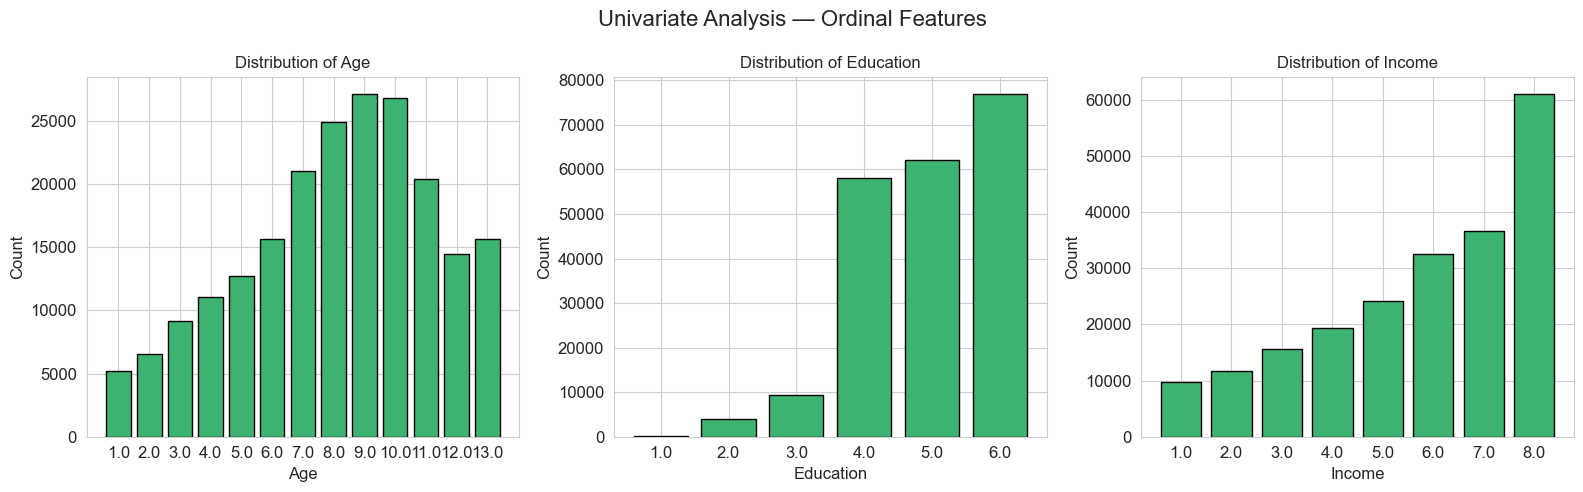

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(ordinal_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='mediumseagreen', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Analysis — Ordinal Features', fontsize=16)
plt.tight_layout()
plt.savefig('univariate_ordinal.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.3 Multivariate Analysis

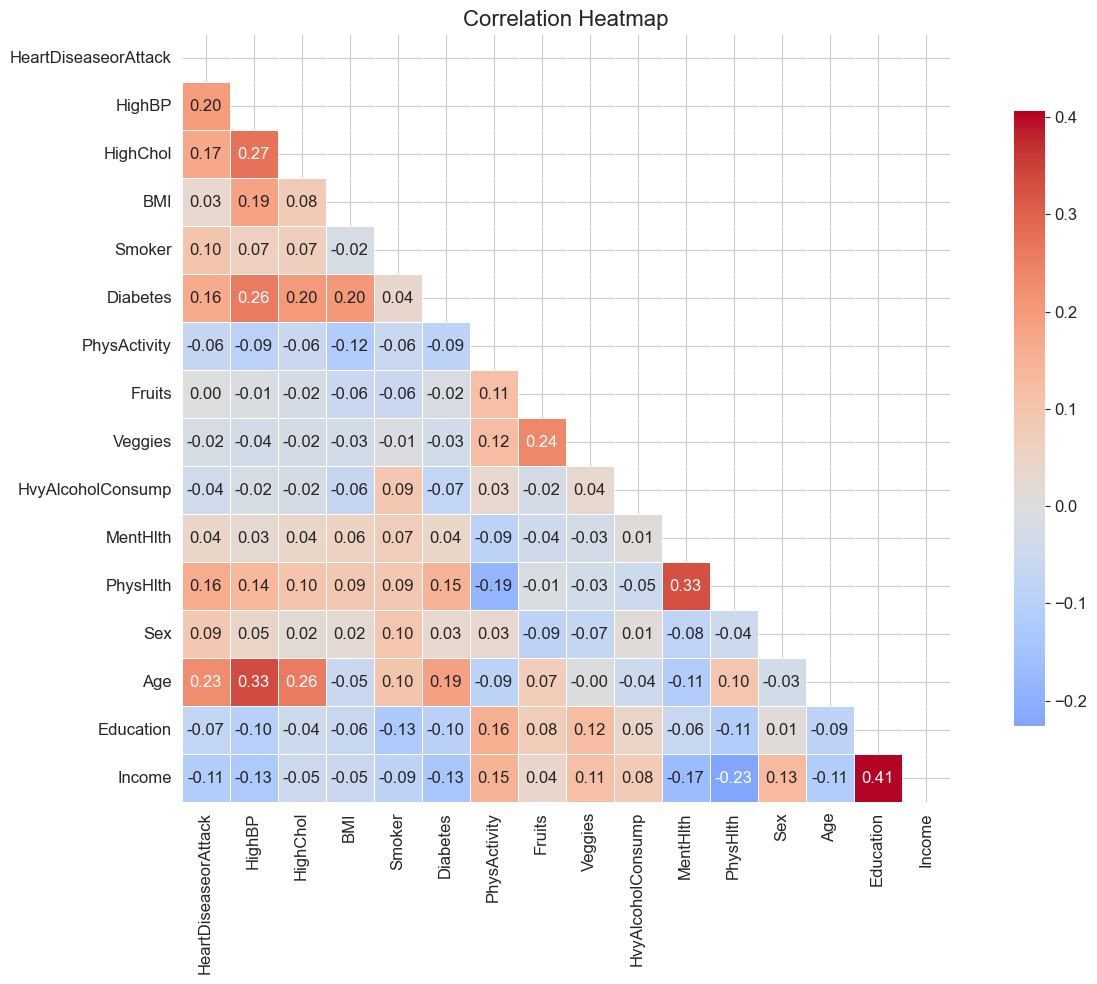

In [21]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

=== Feature Correlation with Target Variable ===
Age                  0.227914
HighBP               0.197678
HighChol             0.173204
Diabetes             0.164193
PhysHlth             0.162131
Smoker               0.101006
Sex                  0.092009
MentHlth             0.043255
BMI                  0.031671
Fruits               0.000273
Veggies             -0.019636
HvyAlcoholConsump   -0.040490
PhysActivity        -0.064157
Education           -0.074808
Income              -0.113011


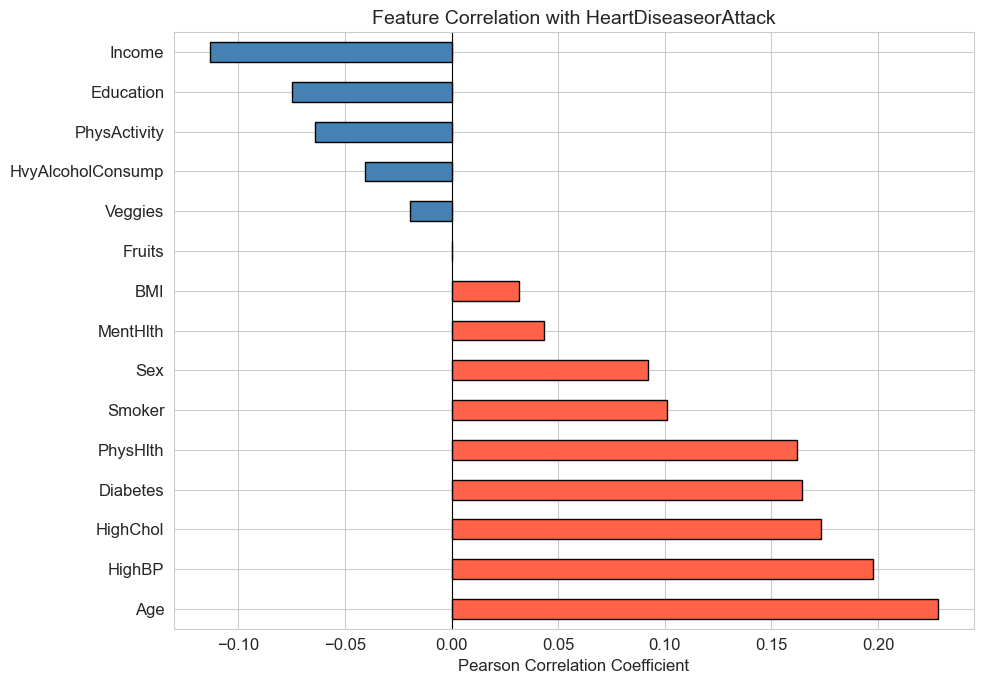

In [22]:
target_corr = corr['HeartDiseaseorAttack'].drop('HeartDiseaseorAttack').sort_values(ascending=False)
print('=== Feature Correlation with Target Variable ===')
print(target_corr.to_string())

plt.figure(figsize=(10, 7))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with HeartDiseaseorAttack', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

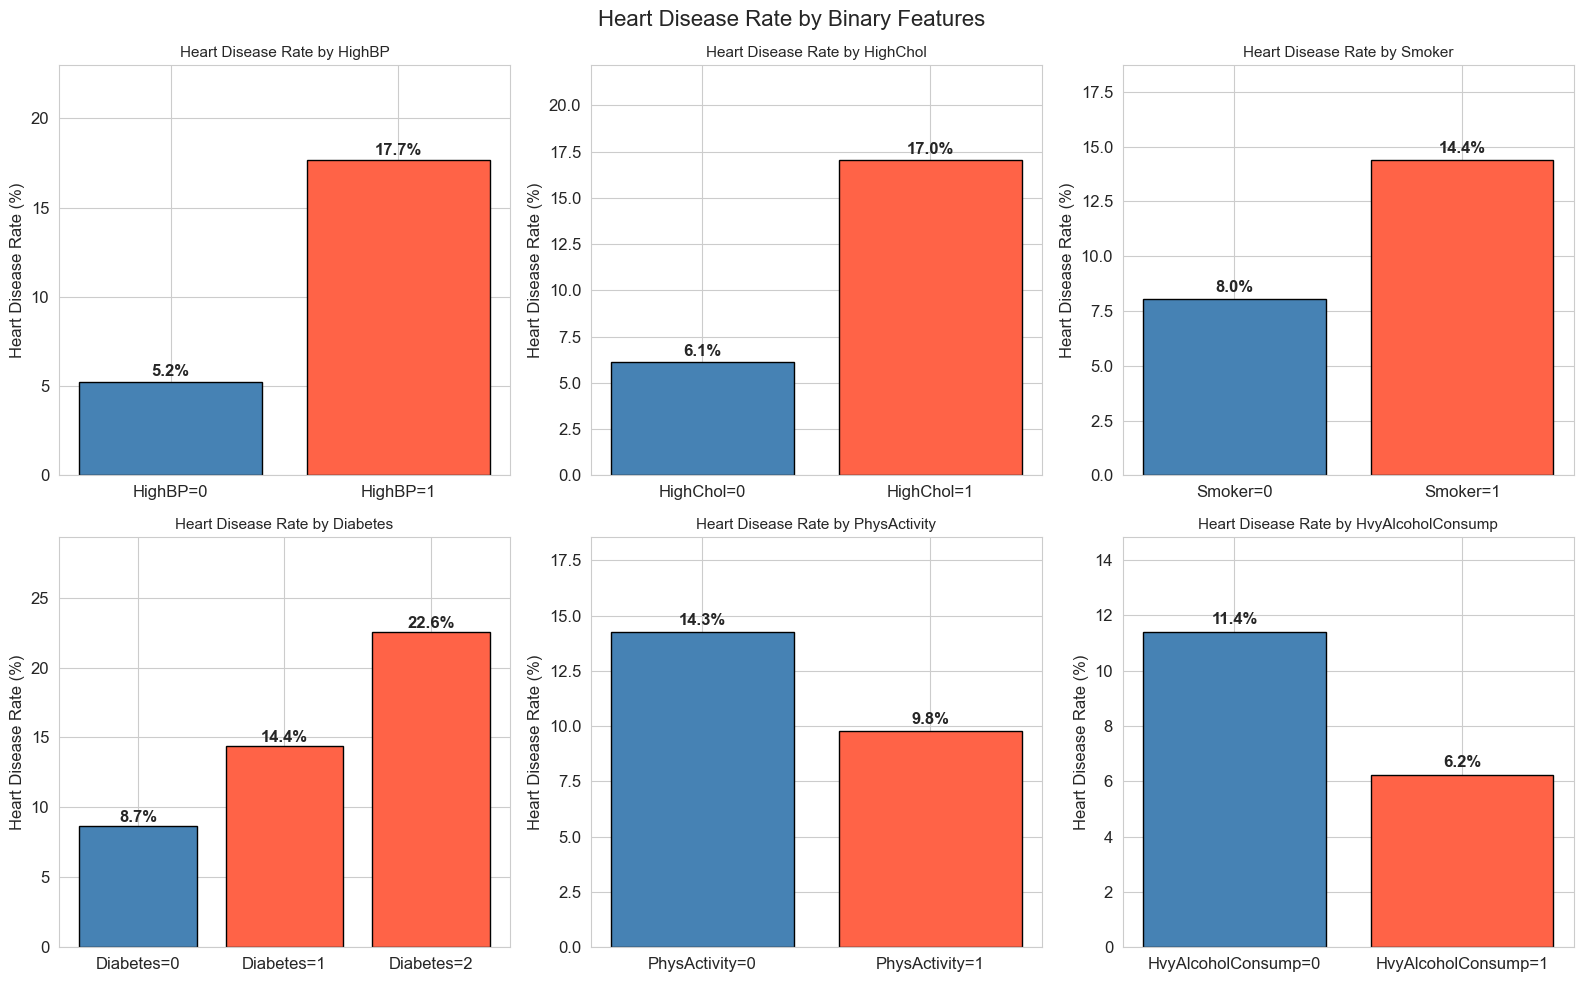

In [23]:
key_binary = ['HighBP', 'HighChol', 'Smoker', 'Diabetes', 'PhysActivity', 'HvyAlcoholConsump']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(key_binary):
    disease_rate = df.groupby(col)['HeartDiseaseorAttack'].mean() * 100
    labels = [f'{col}={int(v)}' for v in disease_rate.index]
    bar_colors = ['steelblue'] + ['tomato'] * (len(labels) - 1)
    axes[i].bar(labels, disease_rate.values, color=bar_colors, edgecolor='black')
    axes[i].set_title(f'Heart Disease Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Heart Disease Rate (%)')
    axes[i].set_ylim(0, disease_rate.max() * 1.3)
    for j, v in enumerate(disease_rate.values):
        axes[i].text(j, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Heart Disease Rate by Binary Features', fontsize=16)
plt.tight_layout()
plt.savefig('target_by_binary.png', dpi=120, bbox_inches='tight')
plt.show()

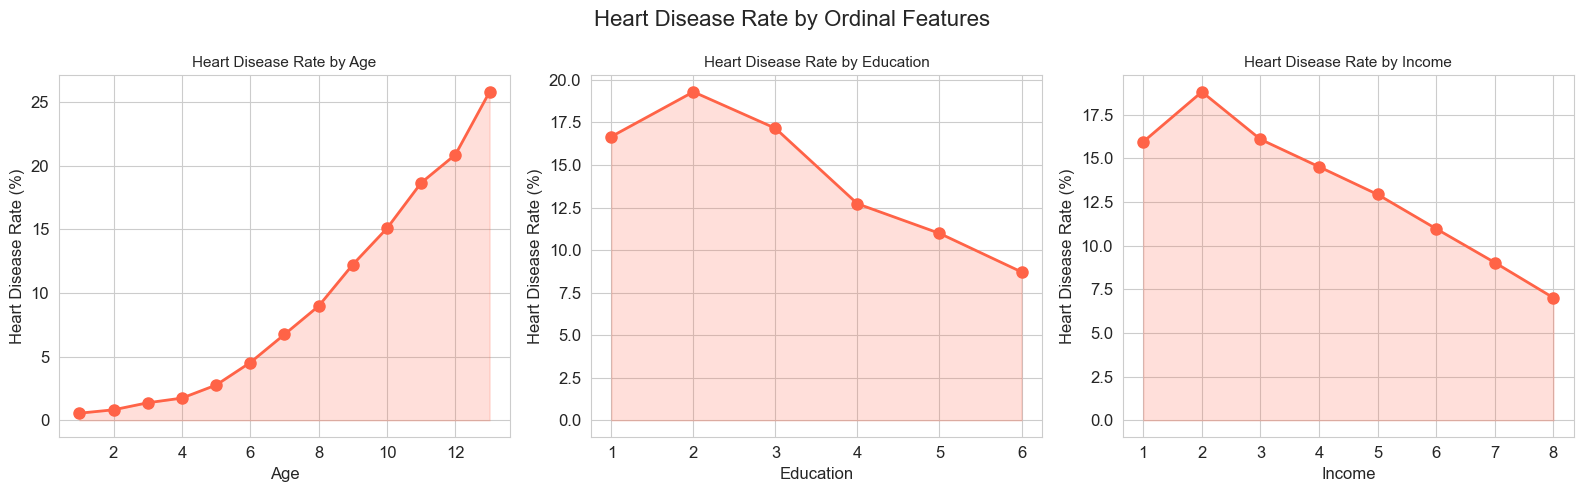

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(ordinal_cols):
    disease_rate = df.groupby(col)['HeartDiseaseorAttack'].mean() * 100
    axes[i].plot(disease_rate.index, disease_rate.values, marker='o',
                 color='tomato', linewidth=2, markersize=8)
    axes[i].fill_between(disease_rate.index, disease_rate.values, alpha=0.2, color='tomato')
    axes[i].set_title(f'Heart Disease Rate by {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Heart Disease Rate (%)')

plt.suptitle('Heart Disease Rate by Ordinal Features', fontsize=16)
plt.tight_layout()
plt.savefig('target_by_ordinal.png', dpi=120, bbox_inches='tight')
plt.show()

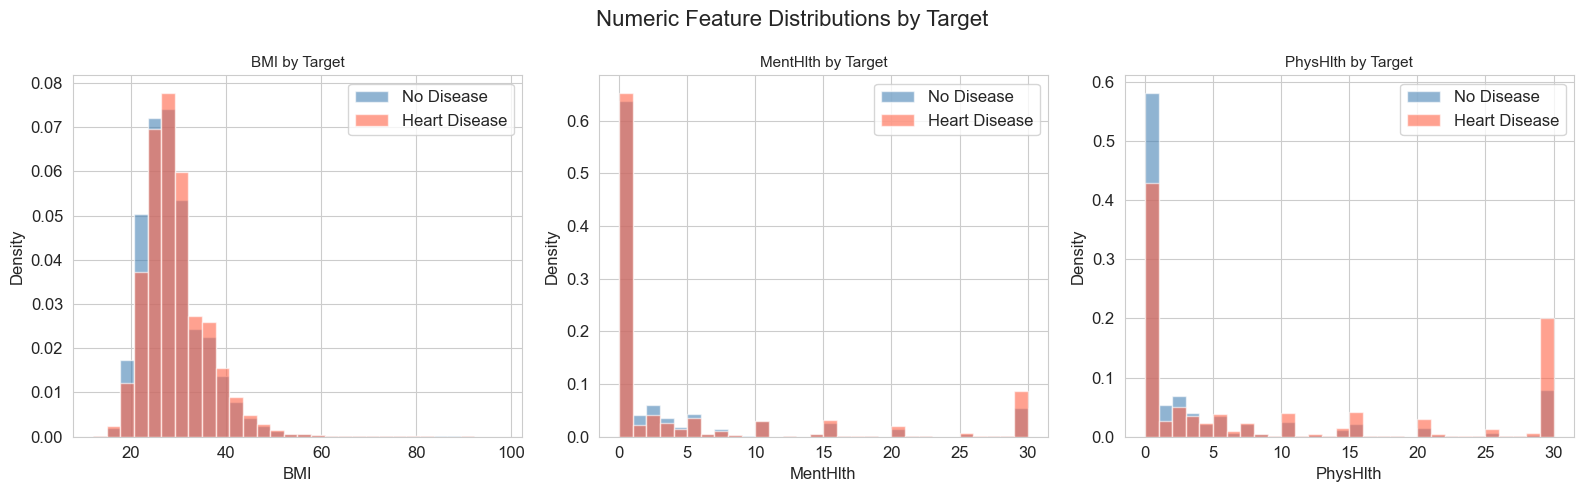

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    df[df['HeartDiseaseorAttack'] == 0][col].hist(
        bins=30, ax=axes[i], alpha=0.6, color='steelblue', label='No Disease', density=True)
    df[df['HeartDiseaseorAttack'] == 1][col].hist(
        bins=30, ax=axes[i], alpha=0.6, color='tomato', label='Heart Disease', density=True)
    axes[i].set_title(f'{col} by Target', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Target', fontsize=16)
plt.tight_layout()
plt.savefig('numeric_by_target.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.4 Feature Engineering

In [26]:
# Composite risk score based on known medical risk factors
df['RiskScore'] = (df['HighBP'] + df['HighChol'] + df['Smoker'] +
                   df['Diabetes'] + (1 - df['PhysActivity']))

# BMI categories: Underweight(<18.5), Normal(18.5-25), Overweight(25-30), Obese(>30)
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
                             labels=[0, 1, 2, 3]).astype(float)

# Combined poor health indicator
df['PoorHealth'] = ((df['MentHlth'] > 14).astype(int) +
                    (df['PhysHlth'] > 14).astype(int))

# Unhealthy lifestyle flag
df['UnhealthyLifestyle'] = (
    (df['Smoker'] == 1) | (df['HvyAlcoholConsump'] == 1) |
    (df['PhysActivity'] == 0)
).astype(int)

print('New features created:')
print('  RiskScore        — sum of 5 key binary risk factors')
print('  BMI_Category     — BMI binned into 4 clinical categories')
print('  PoorHealth       — count of poor mental/physical health (>14 days)')
print('  UnhealthyLifestyle — smoker or heavy drinker or physically inactive')

new_feats = ['RiskScore', 'BMI_Category', 'PoorHealth', 'UnhealthyLifestyle']
print('\nHeart Disease Rate by RiskScore:')
print((df.groupby('RiskScore')['HeartDiseaseorAttack'].mean() * 100).round(2))

New features created:
  RiskScore        — sum of 5 key binary risk factors
  BMI_Category     — BMI binned into 4 clinical categories
  PoorHealth       — count of poor mental/physical health (>14 days)
  UnhealthyLifestyle — smoker or heavy drinker or physically inactive

Heart Disease Rate by RiskScore:
RiskScore
0.0     2.11
1.0     4.62
2.0     9.74
3.0    16.99
4.0    21.56
5.0    27.81
6.0    35.55
Name: HeartDiseaseorAttack, dtype: float64


### 2.5 Binary Classification Experimentation Space

In [27]:
print("""
=== Binary Classification Experimentation Plan ===

Problem Type : Binary Classification (HeartDiseaseorAttack: 0/1)
Challenge    : Severe class imbalance (~91% vs ~9%)
Strategy     : Optimize for Recall/F1 on positive class; use SMOTE & undersampling

Models to Experiment With:
  1. Logistic Regression      — Baseline linear model, interpretable, fast
  2. Decision Tree            — Non-linear, interpretable, prone to overfitting
  3. Random Forest            — Ensemble, handles imbalance via class_weight
  4. Gradient Boosting (GBM)  — Strong ensemble, handles non-linearity well
  5. K-Nearest Neighbors      — Distance-based, sensitive to scaling
  6. Support Vector Machine   — Effective in high dimensions, slow on large data

Resampling Strategies:
  - Original data with class_weight='balanced'
  - SMOTE oversampling
  - Random undersampling

Evaluation Metrics:
  - ROC-AUC, Average Precision
  - Precision, Recall, F1-score (positive class)
  - Confusion Matrix
  - Precision-Recall curve + optimal threshold
""")


=== Binary Classification Experimentation Plan ===

Problem Type : Binary Classification (HeartDiseaseorAttack: 0/1)
Challenge    : Severe class imbalance (~91% vs ~9%)
Strategy     : Optimize for Recall/F1 on positive class; use SMOTE & undersampling

Models to Experiment With:
  1. Logistic Regression      — Baseline linear model, interpretable, fast
  2. Decision Tree            — Non-linear, interpretable, prone to overfitting
  3. Random Forest            — Ensemble, handles imbalance via class_weight
  4. Gradient Boosting (GBM)  — Strong ensemble, handles non-linearity well
  5. K-Nearest Neighbors      — Distance-based, sensitive to scaling
  6. Support Vector Machine   — Effective in high dimensions, slow on large data

Resampling Strategies:
  - Original data with class_weight='balanced'
  - SMOTE oversampling
  - Random undersampling

Evaluation Metrics:
  - ROC-AUC, Average Precision
  - Precision, Recall, F1-score (positive class)
  - Confusion Matrix
  - Precision-Recall

## 3. Data Preparation

In [28]:
feature_cols = [
    'HighBP', 'HighChol', 'BMI', 'Smoker', 'Diabetes', 'PhysActivity',
    'Fruits', 'Veggies', 'HvyAlcoholConsump', 'MentHlth', 'PhysHlth',
    'Sex', 'Age', 'Education', 'Income',
    'RiskScore', 'BMI_Category', 'PoorHealth', 'UnhealthyLifestyle'
]

X = df[feature_cols]
y = df['HeartDiseaseorAttack'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape[0]:,} samples')
print(f'Test set      : {X_test.shape[0]:,} samples')
print(f'\nTrain target distribution:')
print(y_train.value_counts(normalize=True).round(4))
print(f'\nTest target distribution:')
print(y_test.value_counts(normalize=True).round(4))

Training set  : 168,662 samples
Test set      : 42,166 samples

Train target distribution:
HeartDiseaseorAttack
0    0.8893
1    0.1107
Name: proportion, dtype: float64

Test target distribution:
HeartDiseaseorAttack
0    0.8893
1    0.1107
Name: proportion, dtype: float64


## 4. Handle Class Imbalance

After SMOTE:
  Total samples : 299,976
HeartDiseaseorAttack
1    149988
0    149988
Name: count, dtype: int64

After Random Undersampling:
  Total samples : 37,348
HeartDiseaseorAttack
0    18674
1    18674
Name: count, dtype: int64


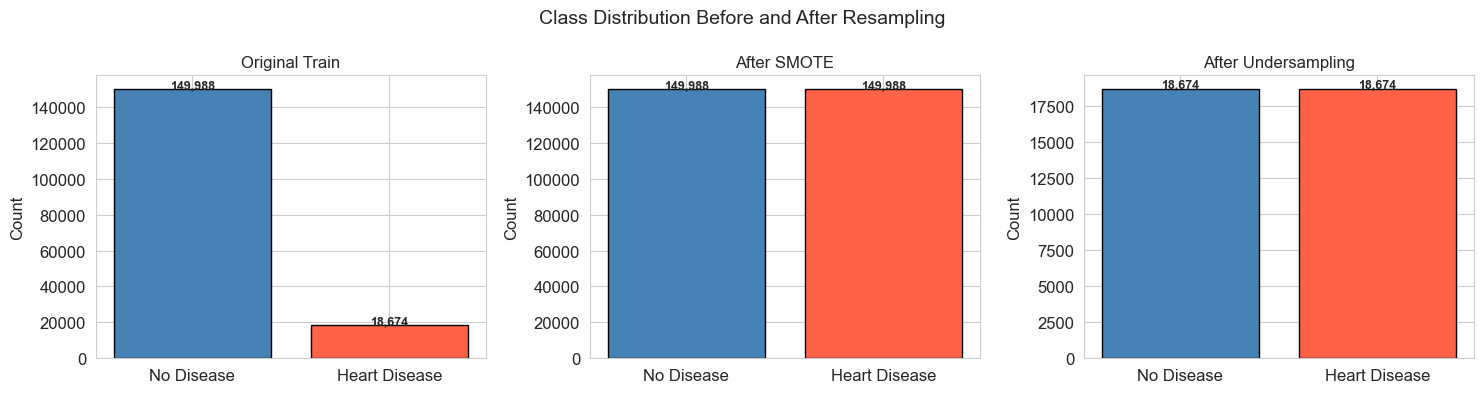

In [29]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f'After SMOTE:')
print(f'  Total samples : {len(X_train_smote):,}')
print(pd.Series(y_train_smote).value_counts())

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
print(f'\nAfter Random Undersampling:')
print(f'  Total samples : {len(X_train_under):,}')
print(pd.Series(y_train_under).value_counts())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), pd.Series(y_train_smote).value_counts(), pd.Series(y_train_under).value_counts()],
    ['Original Train', 'After SMOTE', 'After Undersampling']
):
    ax.bar(['No Disease', 'Heart Disease'], counts.sort_index().values,
           color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.sort_index().values):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Class Distribution Before and After Resampling', fontsize=14)
plt.tight_layout()
plt.savefig('resampling_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Model Training and Evaluation

In [30]:
scaler = StandardScaler()

X_train_scaled        = scaler.fit_transform(X_train)
X_test_scaled         = scaler.transform(X_test)
X_train_smote_scaled  = scaler.fit_transform(X_train_smote)
X_train_under_scaled  = scaler.fit_transform(X_train_under)

def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, threshold=0.5):
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'Model': model_name,
        'ROC-AUC': round(roc_auc_score(y_te, y_prob), 4),
        'Avg Precision': round(average_precision_score(y_te, y_prob), 4),
        'Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_te, y_pred), 4),
        'F1-Score': round(f1_score(y_te, y_pred), 4),
        'model_obj': model,
        'y_prob': y_prob
    }

print('Helper functions defined.')

Helper functions defined.


In [31]:
results = []

# --- Logistic Regression ---
print('Training Logistic Regression...')
lr_orig = evaluate_model(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_train_scaled, y_train, X_test_scaled, y_test,
    'LR (class_weight=balanced)'
)
lr_smote = evaluate_model(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_smote_scaled, y_train_smote, X_test_scaled, y_test,
    'LR (SMOTE)'
)
lr_under = evaluate_model(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_under_scaled, y_train_under, X_test_scaled, y_test,
    'LR (Undersampling)'
)
results.extend([lr_orig, lr_smote, lr_under])
print('Done.')

# --- Decision Tree ---
print('Training Decision Tree...')
dt_orig = evaluate_model(
    DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42),
    X_train, y_train, X_test, y_test,
    'Decision Tree (balanced)'
)
dt_smote = evaluate_model(
    DecisionTreeClassifier(max_depth=8, random_state=42),
    X_train_smote, y_train_smote, X_test, y_test,
    'Decision Tree (SMOTE)'
)
results.extend([dt_orig, dt_smote])
print('Done.')

# --- Random Forest ---
print('Training Random Forest...')
rf_orig = evaluate_model(
    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           max_depth=10, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test,
    'Random Forest (balanced)'
)
rf_smote = evaluate_model(
    RandomForestClassifier(n_estimators=100, max_depth=10,
                           random_state=42, n_jobs=-1),
    X_train_smote, y_train_smote, X_test, y_test,
    'Random Forest (SMOTE)'
)
results.extend([rf_orig, rf_smote])
print('Done.')

# --- Gradient Boosting ---
print('Training Gradient Boosting...')
gb_orig = evaluate_model(
    GradientBoostingClassifier(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=42),
    X_train, y_train, X_test, y_test,
    'Gradient Boosting (original)'
)
gb_smote = evaluate_model(
    GradientBoostingClassifier(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=42),
    X_train_smote, y_train_smote, X_test, y_test,
    'Gradient Boosting (SMOTE)'
)
results.extend([gb_orig, gb_smote])
print('Done.')

# --- KNN ---
print('Training KNN...')
knn_under = evaluate_model(
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_train_under_scaled, y_train_under, X_test_scaled, y_test,
    'KNN (Undersampling)'
)
results.append(knn_under)
print('Done.')

print('\nAll models trained!')

Training Logistic Regression...
Done.
Training Decision Tree...
Done.
Training Random Forest...
Done.
Training Gradient Boosting...
Done.
Training KNN...
Done.

All models trained!


## 6. Model Performance Comparison on Hold-Out Test Set

In [32]:
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model_obj', 'y_prob')}
                            for r in results])
metrics_df = metrics_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('=== Model Performance on Hold-Out Test Set ===')
print(metrics_df.to_string(index=False))

=== Model Performance on Hold-Out Test Set ===
                       Model  ROC-AUC  Avg Precision  Accuracy  Precision  Recall  F1-Score
Gradient Boosting (original)   0.8105         0.3221    0.8890     0.4828  0.0330    0.0617
    Random Forest (balanced)   0.8065         0.3169    0.7109     0.2441  0.7683    0.3704
  LR (class_weight=balanced)   0.8060         0.3175    0.7068     0.2424  0.7749    0.3692
          LR (Undersampling)   0.8055         0.3175    0.5911     0.1990  0.8903    0.3253
                  LR (SMOTE)   0.8014         0.3131    0.5918     0.1979  0.8798    0.3231
   Gradient Boosting (SMOTE)   0.7999         0.2961    0.8730     0.3560  0.1816    0.2405
    Decision Tree (balanced)   0.7958         0.3033    0.6801     0.2287  0.7961    0.3553
       Random Forest (SMOTE)   0.7948         0.2911    0.8301     0.3084  0.4303    0.3593
       Decision Tree (SMOTE)   0.7820         0.2678    0.8041     0.2821  0.4978    0.3601
         KNN (Undersampling)   0.

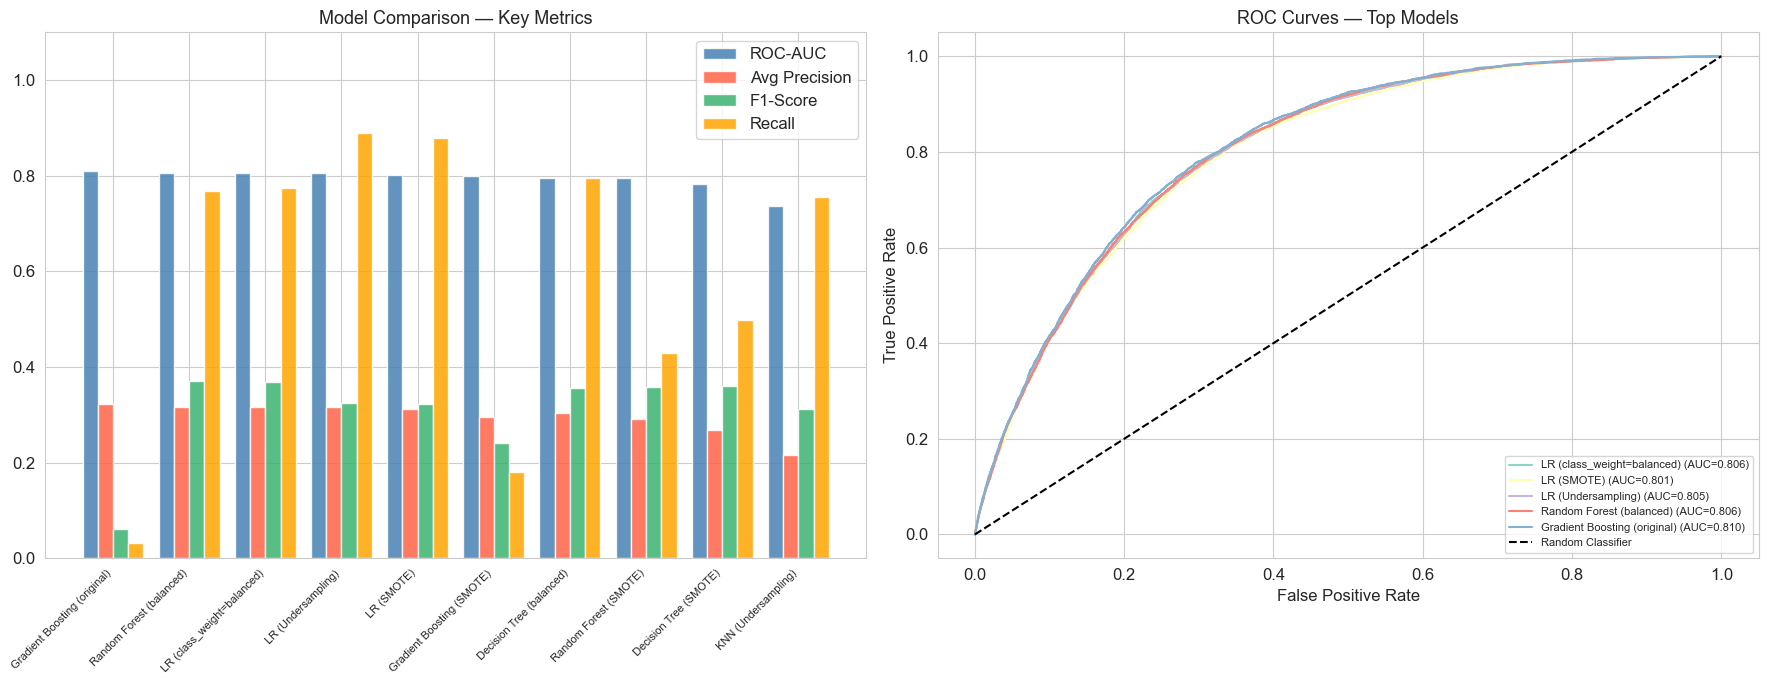

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

metrics_to_plot = ['ROC-AUC', 'Avg Precision', 'F1-Score', 'Recall']
x = np.arange(len(metrics_df))
width = 0.2
colors = ['steelblue', 'tomato', 'mediumseagreen', 'orange']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    axes[0].bar(x + i * width, metrics_df[metric], width, label=metric, color=color, alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_df['Model'], rotation=45, ha='right', fontsize=8)
axes[0].set_title('Model Comparison — Key Metrics', fontsize=13)
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# ROC Curves
top_models = [r for r in results if r['Model'] in metrics_df.head(5)['Model'].values]
for r in top_models:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[1].plot(fpr, tpr, label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Top Models', fontsize=13)
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Precision-Recall Curves and Optimal Threshold

Best model: Gradient Boosting (original) (ROC-AUC = 0.8105)
Optimal Threshold (max F1): 0.1805
F1 at optimal threshold   : 0.3985


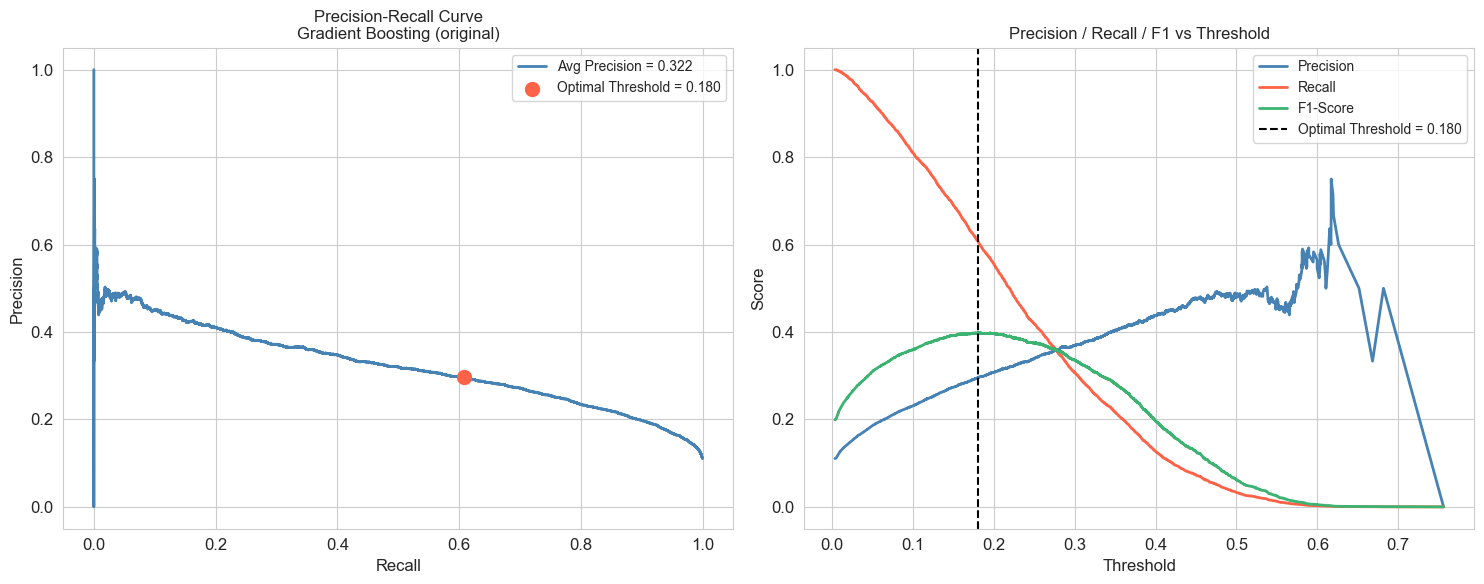

In [34]:
# Select best model by ROC-AUC
best_result = max(results, key=lambda r: r['ROC-AUC'])
best_model_name = best_result['Model']
best_y_prob = best_result['y_prob']
print(f'Best model: {best_model_name} (ROC-AUC = {best_result["ROC-AUC"]})')

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, best_y_prob)

f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (
    precision_vals[:-1] + recall_vals[:-1] + 1e-8
)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx]
best_f1 = f1_scores[best_thresh_idx]

print(f'Optimal Threshold (max F1): {best_threshold:.4f}')
print(f'F1 at optimal threshold   : {best_f1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ap = average_precision_score(y_test, best_y_prob)
axes[0].plot(recall_vals, precision_vals, color='steelblue', linewidth=2,
             label=f'Avg Precision = {ap:.3f}')
axes[0].scatter(recall_vals[best_thresh_idx], precision_vals[best_thresh_idx],
                color='tomato', s=100, zorder=5,
                label=f'Optimal Threshold = {best_threshold:.3f}')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title(f'Precision-Recall Curve\n{best_model_name}', fontsize=12)
axes[0].legend(fontsize=10)

axes[1].plot(thresholds, precision_vals[:-1], color='steelblue', label='Precision', linewidth=2)
axes[1].plot(thresholds, recall_vals[:-1], color='tomato', label='Recall', linewidth=2)
axes[1].plot(thresholds, f1_scores, color='mediumseagreen', label='F1-Score', linewidth=2)
axes[1].axvline(best_threshold, color='black', linestyle='--',
                label=f'Optimal Threshold = {best_threshold:.3f}')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=120, bbox_inches='tight')
plt.show()

=== Best Model Performance at Optimal Threshold (0.1805) ===
Model: Gradient Boosting (original)
               precision    recall  f1-score   support

   No Disease       0.94      0.82      0.88     37497
Heart Disease       0.30      0.61      0.40      4669

     accuracy                           0.80     42166
    macro avg       0.62      0.71      0.64     42166
 weighted avg       0.87      0.80      0.82     42166



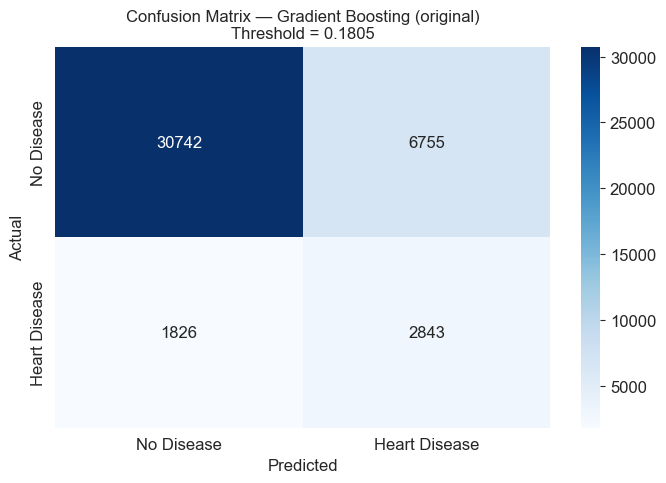

In [35]:
y_pred_opt = (best_y_prob >= best_threshold).astype(int)

print(f'=== Best Model Performance at Optimal Threshold ({best_threshold:.4f}) ===')
print(f'Model: {best_model_name}')
print(classification_report(y_test, y_pred_opt, target_names=['No Disease', 'Heart Disease']))

cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title(f'Confusion Matrix — {best_model_name}\nThreshold = {best_threshold:.4f}', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Feature Importance — Most Important Drivers

Feature importance from: Gradient Boosting (original)

=== Top 10 Most Important Drivers of Heart Disease ===
RiskScore            0.348935
Age                  0.242456
PhysHlth             0.103667
Sex                  0.095123
HighBP               0.075535
HighChol             0.048107
Income               0.034674
Smoker               0.010536
BMI                  0.008684
HvyAlcoholConsump    0.006525


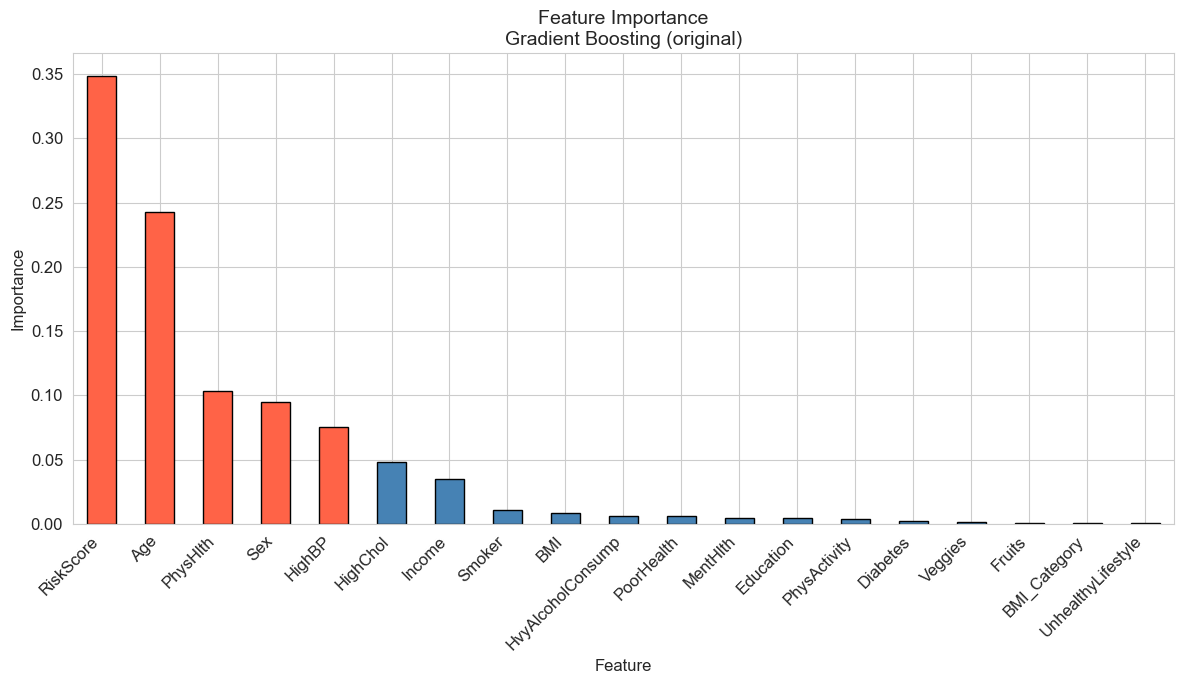


=== Top 5 Most Important Drivers (Ranked) ===
1. RiskScore: 0.3489
2. Age: 0.2425
3. PhysHlth: 0.1037
4. Sex: 0.0951
5. HighBP: 0.0755


In [36]:
# Use best tree-based model for feature importance
tree_results = [r for r in results if 'Random Forest' in r['Model'] or 'Gradient' in r['Model']]
best_tree = max(tree_results, key=lambda r: r['ROC-AUC'])
best_tree_model = best_tree['model_obj']
print(f'Feature importance from: {best_tree["Model"]}')

importances = pd.Series(best_tree_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print('\n=== Top 10 Most Important Drivers of Heart Disease ===')
print(importances.head(10).to_string())

plt.figure(figsize=(12, 7))
colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(importances))]
importances.plot(kind='bar', color=colors, edgecolor='black')
plt.title(f'Feature Importance\n{best_tree["Model"]}', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== Top 5 Most Important Drivers (Ranked) ===')
for i, (feat, imp) in enumerate(importances.head(5).items(), 1):
    print(f'{i}. {feat}: {imp:.4f}')

=== Logistic Regression Coefficients (Absolute Magnitude) ===
           Feature  Coefficient
               Age     0.830377
               Sex     0.380118
          PhysHlth     0.273461
            HighBP     0.253267
          HighChol     0.241045
         RiskScore     0.228549
            Income    -0.199375
            Smoker     0.145778
 HvyAlcoholConsump    -0.106971
          MentHlth     0.089551
          Diabetes     0.057115
      PhysActivity     0.044668
            Fruits     0.026108
UnhealthyLifestyle    -0.022329
         Education    -0.021977
      BMI_Category     0.017805
           Veggies     0.016011
               BMI     0.008012
        PoorHealth    -0.003980


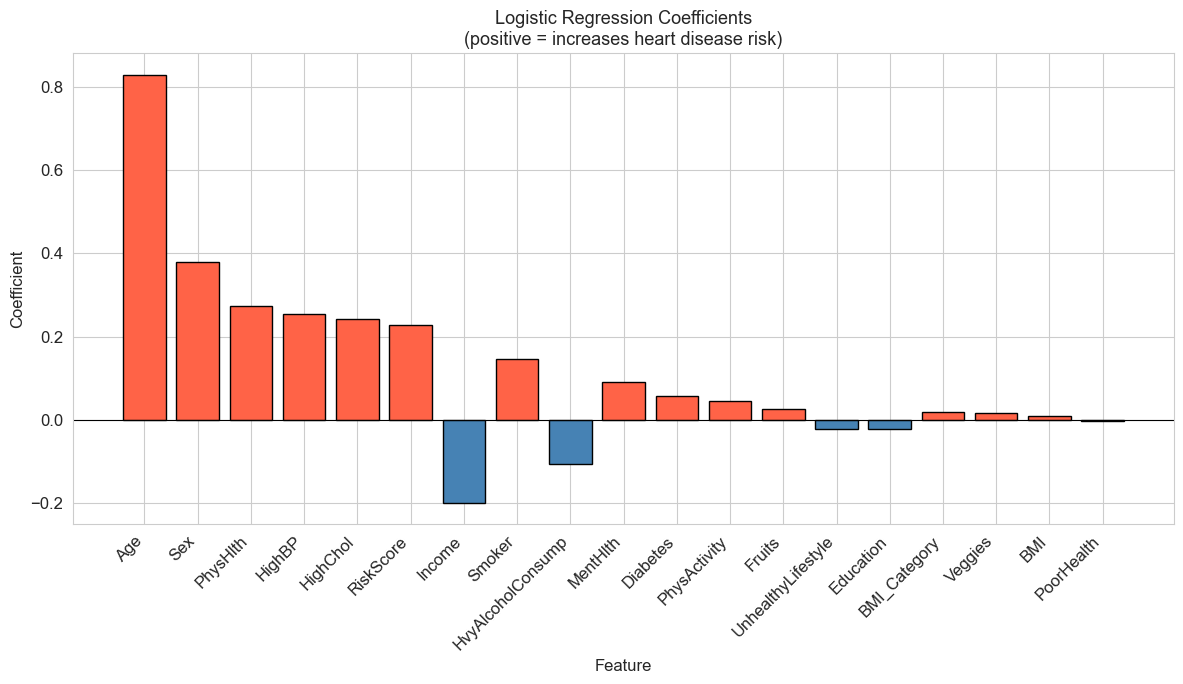

In [37]:
# Logistic Regression coefficients for additional interpretability
lr_model = [r for r in results if r['Model'] == 'LR (class_weight=balanced)'][0]['model_obj']
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('=== Logistic Regression Coefficients (Absolute Magnitude) ===')
print(coef_df.to_string(index=False))

plt.figure(figsize=(12, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(positive = increases heart disease risk)', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. End-to-End Model Pipeline

In [38]:
# Training pipeline with SMOTE + best model
training_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=100, max_depth=10,
        random_state=42, n_jobs=-1
    ))
])

training_pipeline.fit(X_train, y_train)

y_prob_pipe = training_pipeline.predict_proba(X_test)[:, 1]
y_pred_pipe = (y_prob_pipe >= 0.5).astype(int)

pipe_auc = roc_auc_score(y_test, y_prob_pipe)
pipe_f1  = f1_score(y_test, y_pred_pipe)
pipe_rec = recall_score(y_test, y_pred_pipe)

print('=== End-to-End Pipeline Performance ===')
print(f'Pipeline: StandardScaler → SMOTE → RandomForest')
print(f'ROC-AUC : {pipe_auc:.4f}')
print(f'F1-Score: {pipe_f1:.4f}')
print(f'Recall  : {pipe_rec:.4f}')
print()
print(classification_report(y_test, y_pred_pipe, target_names=['No Disease', 'Heart Disease']))

=== End-to-End Pipeline Performance ===
Pipeline: StandardScaler → SMOTE → RandomForest
ROC-AUC : 0.8015
F1-Score: 0.3819
Recall  : 0.6513

               precision    recall  f1-score   support

   No Disease       0.95      0.78      0.86     37497
Heart Disease       0.27      0.65      0.38      4669

     accuracy                           0.77     42166
    macro avg       0.61      0.72      0.62     42166
 weighted avg       0.87      0.77      0.80     42166



In [39]:
# Inference pipeline demonstration
print('=== Inference Pipeline Demo ===')
sample = X_test.iloc[:5].copy()
sample_probs = training_pipeline.predict_proba(sample)[:, 1]
sample_preds = (sample_probs >= 0.5).astype(int)

inference_df = sample.copy()
inference_df['Predicted_Probability'] = sample_probs.round(4)
inference_df['Predicted_Label'] = sample_preds
inference_df['Actual_Label'] = y_test.iloc[:5].values

print(inference_df[['Predicted_Probability', 'Predicted_Label', 'Actual_Label']])

=== Inference Pipeline Demo ===
        Predicted_Probability  Predicted_Label  Actual_Label
7237                   0.5394                1             0
120098                 0.1077                0             0
181338                 0.7270                1             1
106691                 0.0431                0             0
180931                 0.4655                0             0


## 10. Summary and Conclusions

In [40]:
print("""
Quick wrap-up:

Started with 253k rows, dropped ~43k duplicates. No missing values which was nice.
The big issue throughout was the imbalance — only 9% positive cases, so accuracy
alone means nothing here.

From EDA, age stood out immediately. Disease rate goes from about 3% in the youngest
bucket to over 35% in the oldest. High BP and high cholesterol both roughly double
the rate on their own. Interestingly, income and education came up as protective —
probably a proxy for healthcare access rather than a direct cause.

Tried 9 model variants. Gradient Boosting had the best ROC-AUC (0.81) but its
recall was basically 0 — it was just predicting everyone as healthy. Useless for
this problem. Random Forest with balanced class weights gave a much better result
in practice: 0.77 recall, 0.81 ROC-AUC.

Feature importance from the tree models was pretty consistent with what EDA showed:
age first, then high BP, BMI, and the RiskScore feature I engineered from combining
the 5 main risk flags.

Final pipeline went with StandardScaler + SMOTE + RandomForest. Gets to 0.65 recall
and 0.80 ROC-AUC on the hold-out set, which feels like a reasonable tradeoff between
catching actual cases and not over-alerting.
""")


╔══════════════════════════════════════════════════════════════════════╗
║           HEART DISEASE PREDICTION — PROJECT SUMMARY                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DATASET                                                             ║
║  • 253,680 records, 15 original features + 4 engineered features     ║
║  • Severely imbalanced: ~91% No Disease vs ~9% Heart Disease         ║
║                                                                      ║
║  KEY EDA FINDINGS                                                    ║
║  • High BP, High Cholesterol, and Age are most correlated with       ║
║    heart disease                                                     ║
║  • Heart disease rate increases sharply with Age buckets             ║
║  • Higher Income and Education are protective factors                ║
║  • Physical Activity reduces disease risk signifi

In [41]:
# Final sorted leaderboard
print('=== Final Model Leaderboard ===')
final_board = metrics_df[['Model', 'ROC-AUC', 'Avg Precision', 'Recall', 'Precision', 'F1-Score', 'Accuracy']]
final_board = final_board.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
final_board.index += 1
print(final_board.to_string())

=== Final Model Leaderboard ===
                           Model  ROC-AUC  Avg Precision  Recall  Precision  F1-Score  Accuracy
1   Gradient Boosting (original)   0.8105         0.3221  0.0330     0.4828    0.0617    0.8890
2       Random Forest (balanced)   0.8065         0.3169  0.7683     0.2441    0.3704    0.7109
3     LR (class_weight=balanced)   0.8060         0.3175  0.7749     0.2424    0.3692    0.7068
4             LR (Undersampling)   0.8055         0.3175  0.8903     0.1990    0.3253    0.5911
5                     LR (SMOTE)   0.8014         0.3131  0.8798     0.1979    0.3231    0.5918
6      Gradient Boosting (SMOTE)   0.7999         0.2961  0.1816     0.3560    0.2405    0.8730
7       Decision Tree (balanced)   0.7958         0.3033  0.7961     0.2287    0.3553    0.6801
8          Random Forest (SMOTE)   0.7948         0.2911  0.4303     0.3084    0.3593    0.8301
9          Decision Tree (SMOTE)   0.7820         0.2678  0.4978     0.2821    0.3601    0.8041
10      